<h2> Nauczanie maszynowe/Ćwiczenia10

* 17.12.2025, Jadwiga Krząstek

Zagadnienia na dziś:
- reguły asocjacyjne
- drzewa decyzyjne, lasy losowe
- metody prognozowania szeregów czasowych

<h4> Zadanie1 (1 pkt): Rozważ dane Enterococcus_Dataset.csv. Zawiera on dane dotyczące Enterococcus faecium, a dokładniej posiadanych przez nią (bądź nie) genów oporności na antybiotki. Celem będzie zbadanie jakiego typu reguły asocjacyjne występują w tym zbiorze. Wykorzystaj confidence z progiem 0.9. Wypisz przykładowe relacje (2-3), poszukaj w źródłach zewnętrznych informacji o tych genach. Skomentuj otrzymane wyniki.

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules


In [26]:
df = pd.read_csv("Enterococcus_Dataset.csv")
df.head()

,file,gyrA_S83Y,tetM,tetL,liaS_T120A,liaR_W73C,parC_S80R,pbp5_M485A,dfrF,copB,...,ermA,ant9_Ia,vanS_A,vanR_A,aph3p_IIIa,sat4,ant6_Ia,ermB,optrA,fexA
0,CP096219.1.amrfinder.csv,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,KJ571216.1.amrfinder.csv,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CP064343.1.amrfinder.csv,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3,CP042834.1.amrfinder.csv,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,CP023804.1.amrfinder.csv,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [27]:
df_bin = df.drop(columns=["file"])
df_tx = df_tx.astype(bool)

frequent_itemsets = apriori(df_tx, min_support=0.5, use_colnames=True)

print("Liczba częstych zbiorów:", len(frequent_itemsets))
print(frequent_itemsets.head())

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.9)

#sortowanie reguły po confidence i/lub lift
rules_sorted = rules.sort_values(
    by=["confidence", "lift"],
    ascending=False
)

cols_to_show = ["antecedents", "consequents", "support", "confidence", "lift"]
print("\nTop 10 reguł asocjacyjnych (confidence >= 0.9):\n")
print(rules_sorted[cols_to_show].head(10))

Liczba częstych zbiorów: 15
    support            itemsets
0  0.509960        (pbp5_M485A)
1  0.731076              (copB)
2  0.737052           (aac6p_I)
3  0.717131              (msrC)
4  0.505976  (copB, pbp5_M485A)

Top 10 reguł asocjacyjnych (confidence >= 0.9):

                    antecedents      consequents   support  confidence  \
2                  (pbp5_M485A)           (msrC)  0.509960    1.000000   
12           (copB, pbp5_M485A)           (msrC)  0.505976    1.000000   
15        (aac6p_I, pbp5_M485A)           (msrC)  0.507968    1.000000   
24  (copB, aac6p_I, pbp5_M485A)           (msrC)  0.503984    1.000000   
3                        (copB)        (aac6p_I)  0.729084    0.997275   
8                        (msrC)        (aac6p_I)  0.715139    0.997222   
19                 (copB, msrC)        (aac6p_I)  0.709163    0.997199   
17                 (pbp5_M485A)  (aac6p_I, msrC)  0.507968    0.996094   
1                  (pbp5_M485A)        (aac6p_I)  0.507968    0.

#### **Komentarz**:
1. Cztery pierwsze reguły, np. **{pbp5_M485A} -> {msrC}** i **{pbp5_M485A} -> {aac6p_I, msrC}** sugerują, że mutacja PBP5 pojawia się głównie w bakteriach, które mają już oporność na makrolidy [4] (msrC) i aminoglikozydy (aac6p_I). [1]
2. **{copB} → {aac6p_I}** oraz **{copB, msrC} → {aac6p_I}**. Geny copB (mechanizm oporności na miedź [2]), aac6p_I (oporność na aminoglikozydy [3]), msrC (oporność na makrolidy/streptograminy B [4]) wskazują, że istnieje powiązania oporności na miedź, makrolidów i aminoglikozydy.

[1] André Zapun, Carlos Contreras-Martel, Thierry Vernet, *Penicillin-binding proteins and β-lactam resistance*, FEMS Microbiology Reviews, Volume 32, Issue 2, March 2008, Pages 361–385, https://doi.org/10.1111/j.1574-6976.2007.00095.x

[2] Hasman H, Kempf I, Chidaine B, Cariolet R, Ersbøll AK, Houe H, Bruun Hansen HC, Aarestrup FM. *Copper resistance in Enterococcus faecium, mediated by the tcrB gene, is selected by supplementation of pig feed with copper sulfate*. Appl Environ Microbiol. 2006 Sep;72(9):5784-9. doi: 10.1128/AEM.02979-05. PMID: 16957194; PMCID: PMC1563648.

[3] Clyde A. S, Monolekha B, Marta T, Nichole K. S 2 and Sergei B. V. *Aminoglycoside resistance profile and structural architecture of the aminoglycoside acetyltransferase AAC(6’)-Im* Microbial Cell, Vol. 4, No. 12, pp. 402 - 410; doi: 10.15698/mic2017.12.602

[4] Elinor D. Reynolds, Jonathan H. Cove, *Resistance to telithromycin is conferred by msr(A), msrC and msr(D) in Staphylococcus aureus*, Journal of Antimicrobial Chemotherapy, Volume 56, Issue 6, December 2005, Pages 1179–1180, https://doi.org/10.1093/jac/dki378



<h4> Zadanie2 (1 pkt): Rozważ dane dotyczące nowotworu piersi.
    
- Podziel dane na zbiór treningowy i testowy.
    
- Zbuduj model klasyfikacji w oparciu o drzewa losowe. Potestuj różne hiperparametry (ręcznie lub za pomocą GridSearch). Narysuj otrzymane drzewo, zinterpretuj model.

- Z użyciem lasu losowego wskaż które cechy okazały sie najbardziej przydatne przy zadaniu klasyfikacji.

In [38]:
from sklearn import datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import GridSearchCV

In [33]:
bc = datasets.load_breast_cancer()
X, y = bc.data, bc.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y #zachowanie proporcji klas
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.958041958041958
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [34]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [35]:
print(grid.best_params_)
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


{'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy: 0.958041958041958


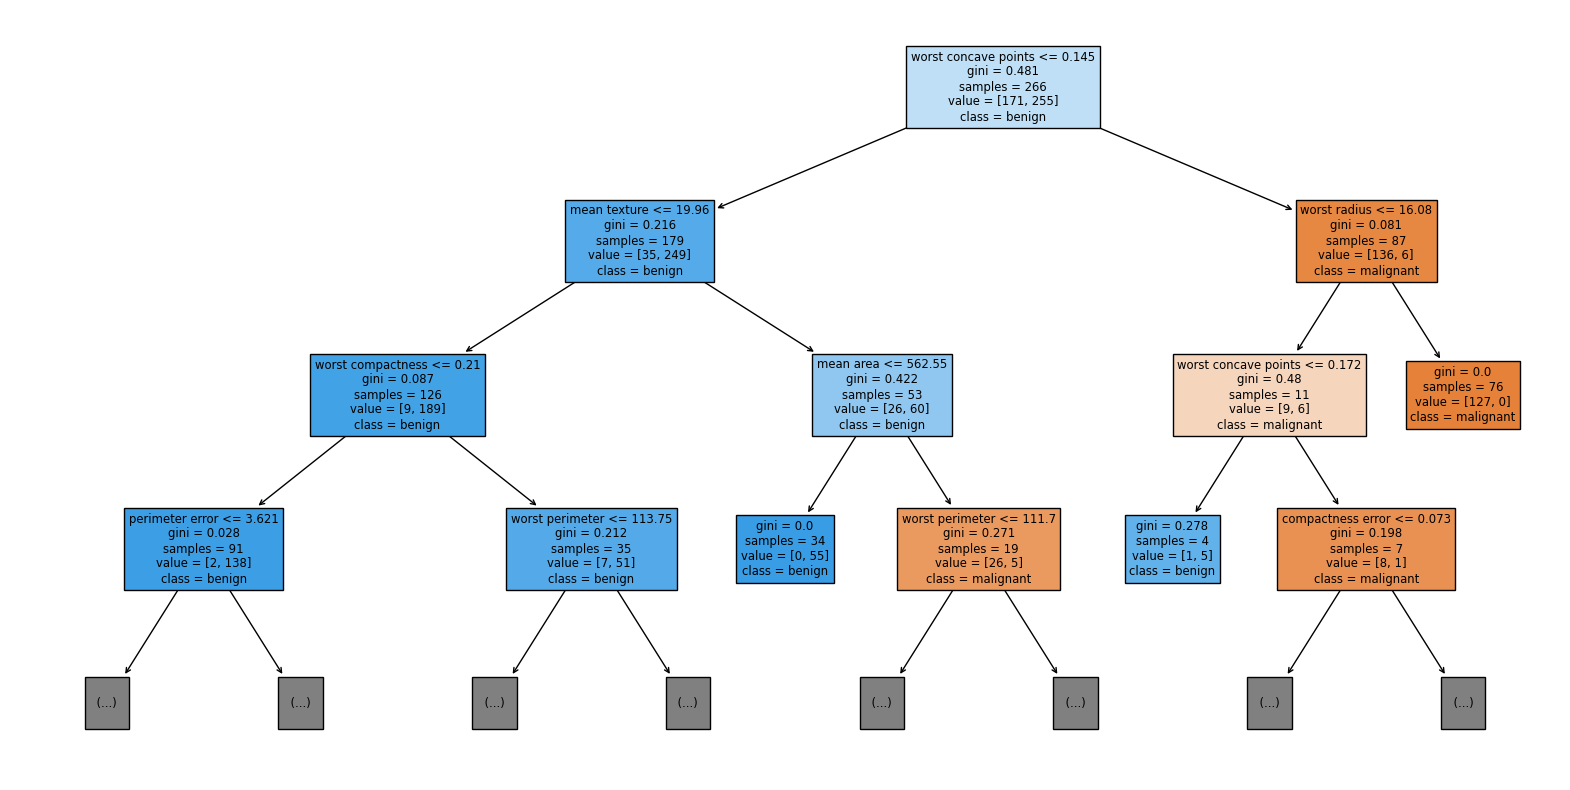

In [36]:
plt.figure(figsize=(20,10))
plot_tree(
    best_rf.estimators_[0],
    feature_names=bc.feature_names,
    class_names=bc.target_names,
    filled=True,
    max_depth=3
)
plt.show()


In [39]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

for i in indices[:10]:
    print(f"{bc.feature_names[i]}: {importances[i]:.4f}")


worst radius: 0.1248
worst concave points: 0.1216
worst area: 0.1200
mean perimeter: 0.0986
mean concavity: 0.0746
mean concave points: 0.0658
worst perimeter: 0.0650
mean radius: 0.0590
mean area: 0.0560
area error: 0.0301


Model Random Forest osiągnął wysoką skuteczność klasyfikacji (>95%). \
Najważniejsze 3 cechy:
- worst radius - promień jądra komórkowego. Duży promień to większe, zdeformowane jądra i większe ryzyko złośliwości
- worst concave points - liczba punktów na obwodzie jądra, które są wklęsłe. Normalnie jądra komórkowe mają gładkie powierzchnie, te złośliwe nieregularne, „poszarpane” brzegi
- worst area - pole powierzchni jądra komórkowego. Guzy złośliwe mają tendencję do szybkiego wzrostu i większej zmienności wielkości komórek

Nowotwory złośliwe charakteryzują się większą nieregularnością kształtu komórek, co potwierdzają powyższe cechy.

<h4> Zadanie3 (2 pkt): Pobierz dowolne historyczne dane pogodowe (np. tempreatura średnia) w wybranym regione (np. Kraków-Balice). Celem jest budowa modelu, który będzie przewidywał wybraną cechę na kilka kolejnych dni. Zrealizuj to na kilka sposobów.

- zbuduj model regresji $X_t \sim f_1(X_{t-1})+f_2(X_{t-2})+...+f_k(X_{t-k})$ dla pewnego $k$ oraz funkcji $f_1,f_2,...,f_k$ (możesz też założyć, że te funkcje nie występują, są identycznościami).
- zbuduj model w oparciu o drzewa losowe (las losowy)
- inne podejścia (np. dane historyczne z analogicznych okresów, biorąc pod uwagę inne miejsca podobne geograficznie (z minionych okresów), uwzględniając inne właściwości pogodowe, np. opady)


Uwagi i komentarze:
- wybierz odpowiednią liczbę danych historycznych (tygodnie/miesiące/lata?); niekoniecznie im więcej danych tym lepiej? np. sezony
- dzieląc dane na zbiór treningowy i testowy zachowaj ciągłość czasową - w danych treningowych mamy okresy wcześniejsze, w danych testowych dane późniejsze
- przy ocenie predykcji możesz użyć miary $MSE$ lub innej
- zwizualizuj zarówno dane historyczne jak i predykcje
- skomentuj otrzymane wyniki

#### Wstęp
Do zadania wybrano temperaturę średnią, średnią prędkość wiatru i opad w grudniu i styczniu w latach 2023 - 2025 w miejscowości Istebna-Kubalonka (gdzie mieszka mój wujek). Dane przekopiowano do dokumentu temp.csv i pobrano do poniższego programu.

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [50]:
df = pd.read_csv("temp.csv", sep = ";", decimal=",")
df.head()

,data,temp,wiatr,opad
0,01.12.2023,-2.0,4.8,3.4
1,02.12.2023,-4.5,9.2,16.5
2,03.12.2023,-7.1,3.8,17.0
3,04.12.2023,-6.6,10.0,2.7
4,05.12.2023,-4.5,12.6,0.0


In [51]:
df.temp[2]+df.temp[44]

-11.7

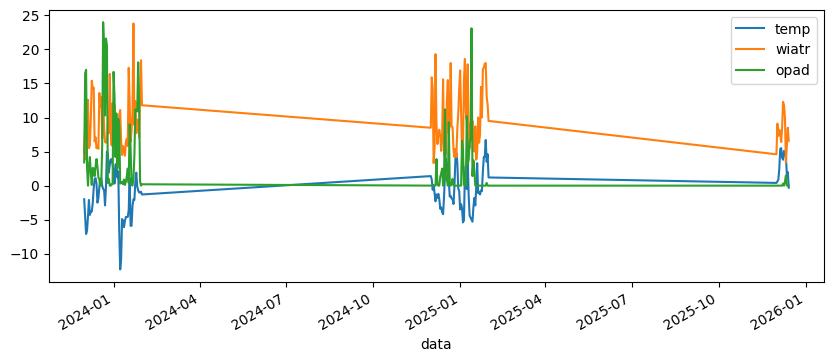

In [56]:
df = pd.read_csv("temp.csv", sep=";", decimal=",")

df["data"] = pd.to_datetime(df["data"], dayfirst=True)

df = df.sort_values("data")
df = df.set_index("data")

df.plot(figsize=(10, 4))
plt.show()


### Część I
Wykorzystajmy dane temp do predykcji temperatury ostatnich kilku dni danych (predykcja 30% czasu).

MSE: 5.914, RMSE: 2.432


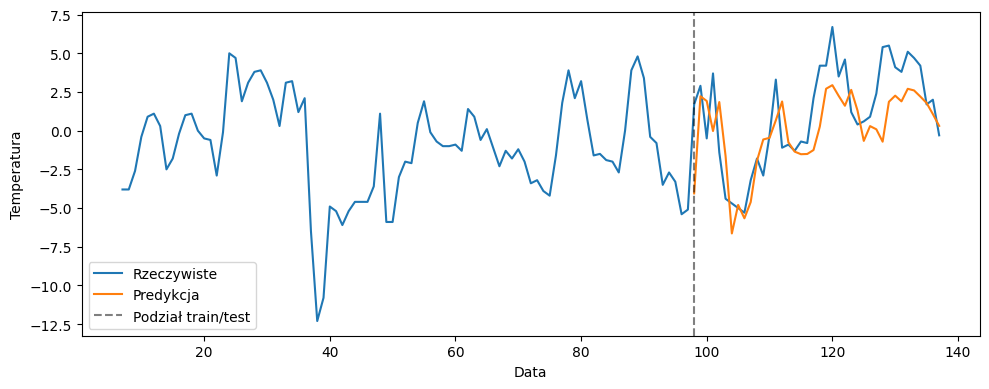

In [60]:
df = pd.read_csv("temp.csv", sep=";", decimal=",")

y = df["temp"].copy() #prognoza temparatury

k = 7 #tydzień
X = pd.DataFrame(index=y.index)

#Xt=tempt, cechy lag_1,...,lag_k to Xt−1,...,Xt−k
for lag in range(1, k + 1):
    X[f"lag_{lag}"] = y.shift(lag)

data = pd.concat([X, y], axis=1).dropna()
X = data.drop(columns=["temp"])
y = data["temp"]

split_idx = int(len(data) * 0.7) #pierwsze 70% czasu train, reszta test
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

#miara oceny MSE i RMSE
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.3f}, RMSE: {rmse:.3f}")

plt.figure(figsize=(10, 4))
#cała seria (historyczne)
plt.plot(y.index, y.values, label="Rzeczywiste", color="C0")

#predykcje tylko na testowym
plt.plot(y_test.index, y_pred, label="Predykcja", color="C1")

plt.axvline(x=y_test.index[0], color="k", linestyle="--", alpha=0.5,
            label="Podział train/test")

plt.xlabel("Data")
plt.ylabel("Temperatura")
plt.legend()
plt.tight_layout()
plt.show()

#### **Komentarz:**
tydzień historii przy danych dziennych pozwala na dość dobre oszacowanie ostatniego fragmentu czasu. Pod koniec predykcja staje się coraz mniej dokładna.

### Część II
Wykorzystajmy teraz dodatkowo dane dotyczące wiatru i opadów - prognoza na podstawie 3 zmiennych. Spróbujmy też oszacować do 2 tygodni w przyszłości.

MSE: 6.952
RMSE: 2.637


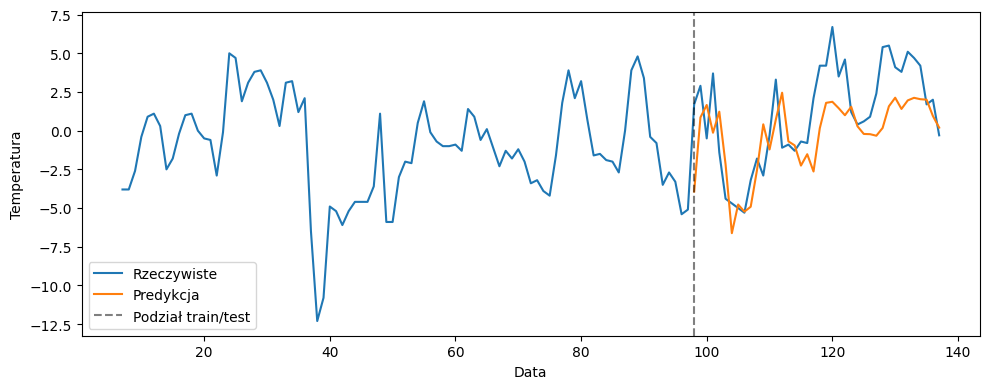

In [6]:
X["temp_lag_1"] = df["temp"].shift(lag)
X["wiatr_lag_2"] = df["wiatr"].shift(lag)
X["opad_lag_3"] = df["opad"].shift(lag)

data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=["temp"])
y = data["temp"]

split_idx = int(len(data) * 0.7)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

plt.figure(figsize=(10, 4))

plt.plot(y.index, y.values, label="Rzeczywiste", color="C0")
plt.plot(y_test.index, y_pred, label="Predykcja", color="C1")

plt.axvline(
    x=y_test.index[0],
    color="k",
    linestyle="--",
    alpha=0.5,
    label="Podział train/test"
)

plt.xlabel("Data")
plt.ylabel("Temperatura")
plt.legend()
plt.tight_layout()
plt.show()


#### **Komentarz**:
model | MSE | RMSE |
------ | ------ | ------- |
temp | 5.914 | 2.432 |
temp+wiatr+opad | 6.952 | 2.637 |

Parametry gorsze przy wzięciu pod uwagę trzech czynników zamiast jednego. Być może opad i wiatr nie mają tego typu silnej i bezpośredniej zależności od temperatury.
